In [1]:
import os
import random
import numpy as np
import pandas as pd

from scipy.sparse import load_npz

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [14]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

LABELS_PATH = "../data_2/sider_lincs_labels_cid_filtered_by_gadr.csv"
ADR_INDEX_PATH = "../data_2/adr_index_filtered.csv"
GADR_PATH = "../data_2/Gadr_filtered.npz"

DRUG_INDEX_PATH = "../data_2/drug_index.csv"
GDRUG_PATH = "../data_2/Gdrug_eff.npy"

Using device: cpu


In [5]:
labels = pd.read_csv(LABELS_PATH)
adr_index = pd.read_csv(ADR_INDEX_PATH)
drug_index = pd.read_csv(DRUG_INDEX_PATH)

Gadr = load_npz(GADR_PATH).toarray().astype(np.float32)
Gdrug = np.load(GDRUG_PATH).astype(np.float32)

print("labels shape:", labels.shape)
print("adr_index shape:", adr_index.shape)
print("drug_index shape:", drug_index.shape)
print("Gadr shape:", Gadr.shape)
print("Gdrug shape:", Gdrug.shape)

labels shape: (57030, 8)
adr_index shape: (1347, 3)
drug_index shape: (820, 2)
Gadr shape: (1347, 978)
Gdrug shape: (820, 978)


In [6]:
assert Gdrug.shape[0] == len(drug_index), "Mismatch between Gdrug rows and drug_index rows."
assert Gadr.shape[0] == len(adr_index), "Mismatch between Gadr rows and adr_index rows."

assert "pert_id" in drug_index.columns
assert "drug_idx" in drug_index.columns
assert "adr_id" in adr_index.columns
assert "adr_idx" in adr_index.columns
assert "pert_id" in labels.columns
assert "adr_id" in labels.columns

drug_index["pert_id"] = drug_index["pert_id"].astype(str)
adr_index["adr_id"] = adr_index["adr_id"].astype(str)
labels["pert_id"] = labels["pert_id"].astype(str)
labels["adr_id"] = labels["adr_id"].astype(str)

drug_to_idx = dict(zip(drug_index["pert_id"], drug_index["drug_idx"]))
adr_to_idx = dict(zip(adr_index["adr_id"], adr_index["adr_idx"]))

labels = labels[
    labels["pert_id"].isin(drug_to_idx) &
    labels["adr_id"].isin(adr_to_idx)
].copy().reset_index(drop=True)

labels["drug_idx"] = labels["pert_id"].map(drug_to_idx)
labels["adr_idx"] = labels["adr_id"].map(adr_to_idx)

labels = labels[["drug_idx", "adr_idx"]].drop_duplicates().reset_index(drop=True)

print("Aligned positive labels shape:", labels.shape)
print(labels.head())

Aligned positive labels shape: (52898, 2)
   drug_idx  adr_idx
0       165       21
1       165      752
2       165      112
3       165      130
4       165      144


In [7]:
num_drugs = len(drug_index)
num_adrs = len(adr_index)

drug_to_pos_adrs = labels.groupby("drug_idx")["adr_idx"].apply(set).to_dict()

all_drugs_with_positives = sorted(drug_to_pos_adrs.keys())

print("Total indexed drugs:", num_drugs)
print("Total indexed ADRs:", num_adrs)
print("Drugs with at least one positive ADR:", len(all_drugs_with_positives))

example_drug = all_drugs_with_positives[0]
print("Example drug_idx:", example_drug)
print("Number of positives for that drug:", len(drug_to_pos_adrs[example_drug]))

Total indexed drugs: 820
Total indexed ADRs: 1347
Drugs with at least one positive ADR: 820
Example drug_idx: 0
Number of positives for that drug: 9


In [8]:
from sklearn.model_selection import train_test_split

train_drugs, temp_drugs = train_test_split(
    all_drugs_with_positives,
    test_size=0.30,
    random_state=SEED
)

val_drugs, test_drugs = train_test_split(
    temp_drugs,
    test_size=0.50,
    random_state=SEED
)

train_drugs = sorted(train_drugs)
val_drugs = sorted(val_drugs)
test_drugs = sorted(test_drugs)

print("Train drugs:", len(train_drugs))
print("Val drugs:", len(val_drugs))
print("Test drugs:", len(test_drugs))

Train drugs: 574
Val drugs: 123
Test drugs: 123


In [9]:
def build_subset_dict(drug_list, full_dict):
    subset = {}
    for d in drug_list:
        subset[d] = set(full_dict[d])
    return subset

train_pos_dict = build_subset_dict(train_drugs, drug_to_pos_adrs)
val_pos_dict = build_subset_dict(val_drugs, drug_to_pos_adrs)
test_pos_dict = build_subset_dict(test_drugs, drug_to_pos_adrs)

print("Train subset example:", list(train_pos_dict.items())[:1])

Train subset example: [(0, {518, 488, 746, 942, 559, 144, 17, 307, 286})]


In [10]:
class RankingTripletDataset(Dataset):
    def __init__(self, drug_to_pos_adrs, num_adrs, num_samples_per_drug=20):
        self.drug_to_pos_adrs = drug_to_pos_adrs
        self.num_adrs = num_adrs
        self.num_samples_per_drug = num_samples_per_drug

        self.drugs = sorted(drug_to_pos_adrs.keys())

        self.samples = []
        for d in self.drugs:
            pos_list = list(drug_to_pos_adrs[d])

            if len(pos_list) == 0:
                continue

            for _ in range(num_samples_per_drug):
                pos_adr = random.choice(pos_list)

                while True:
                    neg_adr = random.randint(0, self.num_adrs - 1)
                    if neg_adr not in self.drug_to_pos_adrs[d]:
                        break

                self.samples.append((d, pos_adr, neg_adr))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        d, pos_a, neg_a = self.samples[idx]
        return (
            torch.tensor(d, dtype=torch.long),
            torch.tensor(pos_a, dtype=torch.long),
            torch.tensor(neg_a, dtype=torch.long)
        )

In [11]:
TRAIN_SAMPLES_PER_DRUG = 30
VAL_SAMPLES_PER_DRUG = 10

train_dataset = RankingTripletDataset(
    train_pos_dict,
    num_adrs=num_adrs,
    num_samples_per_drug=TRAIN_SAMPLES_PER_DRUG
)

val_dataset = RankingTripletDataset(
    val_pos_dict,
    num_adrs=num_adrs,
    num_samples_per_drug=VAL_SAMPLES_PER_DRUG
)

BATCH_SIZE = 256

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train triplets:", len(train_dataset))
print("Val triplets:", len(val_dataset))

Train triplets: 17220
Val triplets: 1230


In [12]:
drug_mean = Gdrug[train_drugs].mean(axis=0, keepdims=True)
drug_std = Gdrug[train_drugs].std(axis=0, keepdims=True)
drug_std[drug_std < 1e-8] = 1.0

Gdrug_std = ((Gdrug - drug_mean) / drug_std).astype(np.float32)

adr_mean = Gadr.mean(axis=0, keepdims=True)
adr_std = Gadr.std(axis=0, keepdims=True)
adr_std[adr_std < 1e-8] = 1.0

Gadr_std = ((Gadr - adr_mean) / adr_std).astype(np.float32)

print("Standardized Gdrug shape:", Gdrug_std.shape)
print("Standardized Gadr shape:", Gadr_std.shape)

Standardized Gdrug shape: (820, 978)
Standardized Gadr shape: (1347, 978)


In [13]:
class PairScorer(nn.Module):
    def __init__(self, drug_dim, adr_dim):
        super().__init__()

        input_dim = drug_dim + adr_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, 1)
        )

    def forward(self, drug_feat, adr_feat):
        x = torch.cat([drug_feat, adr_feat], dim=1)
        return self.net(x).squeeze(1)

drug_dim = Gdrug_std.shape[1]
adr_dim = Gadr_std.shape[1]

model = PairScorer(drug_dim, adr_dim).to(device)
print(model)

PairScorer(
  (net): Sequential(
    (0): Linear(in_features=1956, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
  )
)


In [15]:
# device= cpu
Gdrug_tensor = torch.tensor(Gdrug_std, dtype=torch.float32, device=device)
Gadr_tensor = torch.tensor(Gadr_std, dtype=torch.float32, device=device)

ranking_loss_fn = nn.MarginRankingLoss(margin=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

EPOCHS = 20
BEST_MODEL_PATH = "best_ranking_model_case2.pt"

In [16]:
def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()

    epoch_losses = []

    for drug_idx_batch, pos_adr_batch, neg_adr_batch in loader:
        drug_idx_batch = drug_idx_batch.to(device)
        pos_adr_batch = pos_adr_batch.to(device)
        neg_adr_batch = neg_adr_batch.to(device)

        drug_feat = Gdrug_tensor[drug_idx_batch]
        pos_adr_feat = Gadr_tensor[pos_adr_batch]
        neg_adr_feat = Gadr_tensor[neg_adr_batch]

        pos_scores = model(drug_feat, pos_adr_feat)
        neg_scores = model(drug_feat, neg_adr_feat)

        target = torch.ones_like(pos_scores, device=device)

        loss = loss_fn(pos_scores, neg_scores, target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_losses.append(loss.item())

    return float(np.mean(epoch_losses))

In [17]:
def evaluate_ranking_triplets(model, loader, loss_fn):
    model.eval()

    losses = []
    correct = 0
    total = 0

    with torch.no_grad():
        for drug_idx_batch, pos_adr_batch, neg_adr_batch in loader:
            drug_idx_batch = drug_idx_batch.to(device)
            pos_adr_batch = pos_adr_batch.to(device)
            neg_adr_batch = neg_adr_batch.to(device)

            drug_feat = Gdrug_tensor[drug_idx_batch]
            pos_adr_feat = Gadr_tensor[pos_adr_batch]
            neg_adr_feat = Gadr_tensor[neg_adr_batch]

            pos_scores = model(drug_feat, pos_adr_feat)
            neg_scores = model(drug_feat, neg_adr_feat)

            target = torch.ones_like(pos_scores, device=device)
            loss = loss_fn(pos_scores, neg_scores, target)

            losses.append(loss.item())

            correct += (pos_scores > neg_scores).sum().item()
            total += len(pos_scores)

    return {
        "loss": float(np.mean(losses)),
        "pairwise_accuracy": float(correct / total) if total > 0 else 0.0
    }

In [18]:
def compute_recall_at_k(model, eval_drugs, drug_to_pos_adrs, Gdrug_tensor, Gadr_tensor, k=10):
    model.eval()

    recalls = []

    with torch.no_grad():
        all_adr_feat = Gadr_tensor

        for d in eval_drugs:
            true_adrs = drug_to_pos_adrs[d]

            if len(true_adrs) == 0:
                continue

            drug_feat = Gdrug_tensor[d].unsqueeze(0).repeat(len(all_adr_feat), 1)

            scores = model(drug_feat, all_adr_feat).cpu().numpy()

            topk_idx = np.argsort(-scores)[:k]
            topk_set = set(topk_idx.tolist())

            hits = len(topk_set.intersection(true_adrs))
            recall = hits / len(true_adrs)

            recalls.append(recall)

    return float(np.mean(recalls)) if len(recalls) > 0 else 0.0

In [19]:
best_val_recall10 = -1.0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, ranking_loss_fn)

    val_triplet_metrics = evaluate_ranking_triplets(model, val_loader, ranking_loss_fn)

    val_recall10 = compute_recall_at_k(
        model,
        val_drugs,
        val_pos_dict,
        Gdrug_tensor,
        Gadr_tensor,
        k=10
    )

    val_recall50 = compute_recall_at_k(
        model,
        val_drugs,
        val_pos_dict,
        Gdrug_tensor,
        Gadr_tensor,
        k=50
    )

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_triplet_metrics['loss']:.4f} | "
        f"val_pair_acc={val_triplet_metrics['pairwise_accuracy']:.4f} | "
        f"val_R@10={val_recall10:.4f} | "
        f"val_R@50={val_recall50:.4f}"
    )

    if val_recall10 > best_val_recall10:
        best_val_recall10 = val_recall10
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Saved best model based on validation Recall@10")

Epoch 01/20 | train_loss=0.6424 | val_loss=0.4668 | val_pair_acc=0.8008 | val_R@10=0.1127 | val_R@50=0.2630
Saved best model based on validation Recall@10
Epoch 02/20 | train_loss=0.4877 | val_loss=0.4514 | val_pair_acc=0.8138 | val_R@10=0.1145 | val_R@50=0.2664
Saved best model based on validation Recall@10
Epoch 03/20 | train_loss=0.4421 | val_loss=0.4338 | val_pair_acc=0.8138 | val_R@10=0.1169 | val_R@50=0.2735
Saved best model based on validation Recall@10
Epoch 04/20 | train_loss=0.4122 | val_loss=0.4224 | val_pair_acc=0.8220 | val_R@10=0.1087 | val_R@50=0.2809
Epoch 05/20 | train_loss=0.3949 | val_loss=0.4277 | val_pair_acc=0.8179 | val_R@10=0.1106 | val_R@50=0.2815
Epoch 06/20 | train_loss=0.3715 | val_loss=0.4346 | val_pair_acc=0.8089 | val_R@10=0.1134 | val_R@50=0.2847
Epoch 07/20 | train_loss=0.3539 | val_loss=0.4495 | val_pair_acc=0.8130 | val_R@10=0.1117 | val_R@50=0.2719
Epoch 08/20 | train_loss=0.3351 | val_loss=0.4413 | val_pair_acc=0.8146 | val_R@10=0.1142 | val_R@50=0.

In [20]:
print("Total indexed ADRs:", num_adrs)

Total indexed ADRs: 1347


In [21]:
def compute_ranking_metrics(
    model,
    eval_drugs,
    drug_to_pos_adrs,
    Gdrug_tensor,
    Gadr_tensor,
    ks=(10, 50)
):
    model.eval()

    results = {}

    # Store per-drug values for each metric.
    recall_at_k = {k: [] for k in ks}
    precision_at_k = {k: [] for k in ks}
    hitrate_at_k = {k: [] for k in ks}
    ndcg_at_k = {k: [] for k in ks}

    mrr_list = []
    mpr_list = []
    mean_rank_list = []
    median_rank_list = []

    with torch.no_grad():
        all_adr_feat = Gadr_tensor
        num_adrs = all_adr_feat.shape[0]

        for d in eval_drugs:
            true_adrs = drug_to_pos_adrs[d]

            # Skip drugs with no positives, though this should not happen here.
            if len(true_adrs) == 0:
                continue

            # Score all ADRs for this drug.
            drug_feat = Gdrug_tensor[d].unsqueeze(0).repeat(num_adrs, 1)
            scores = model(drug_feat, all_adr_feat).cpu().numpy()

            # Descending ranking: highest score first.
            order = np.argsort(-scores)

            # rank_map[a] = rank position of ADR a, where rank 0 is best.
            rank_map = np.empty_like(order)
            rank_map[order] = np.arange(len(order))

            # Collect ranks of all true ADRs.
            true_ranks = np.array([rank_map[a] for a in true_adrs], dtype=np.int64)

            # -------- MRR --------
            # Reciprocal rank uses the best (lowest) true rank.
            best_rank = true_ranks.min()
            mrr_list.append(1.0 / (best_rank + 1))

            # -------- MPR --------
            # Higher percentile means better ranking.
            # rank 0 -> percentile 1.0
            # rank num_adrs-1 -> percentile 0.0
            if num_adrs > 1:
                percentiles = 1.0 - (true_ranks / (num_adrs - 1))
            else:
                percentiles = np.ones_like(true_ranks, dtype=np.float64)

            mpr_list.append(float(np.mean(percentiles)))

            # -------- Mean / Median rank --------
            # Convert to 1-based ranks for readability.
            mean_rank_list.append(float(np.mean(true_ranks + 1)))
            median_rank_list.append(float(np.median(true_ranks + 1)))

            # -------- Metrics at K --------
            true_set = set(true_adrs)

            for k in ks:
                k_eff = min(k, num_adrs)
                topk = order[:k_eff]
                topk_set = set(topk.tolist())

                hits = len(topk_set.intersection(true_set))

                # Recall@K = fraction of true ADRs recovered in top K.
                recall = hits / len(true_set)

                # Precision@K = fraction of top K predictions that are correct.
                precision = hits / k_eff

                # HitRate@K = did we get at least one correct ADR in top K?
                hitrate = 1.0 if hits > 0 else 0.0

                # NDCG@K
                # Binary relevance: an ADR is relevant if it is in the true set.
                dcg = 0.0
                for idx, adr in enumerate(topk):
                    if adr in true_set:
                        dcg += 1.0 / np.log2(idx + 2)

                # Ideal DCG: all relevant items ranked at the top.
                ideal_hits = min(len(true_set), k_eff)
                idcg = sum(1.0 / np.log2(i + 2) for i in range(ideal_hits))

                ndcg = dcg / idcg if idcg > 0 else 0.0

                recall_at_k[k].append(recall)
                precision_at_k[k].append(precision)
                hitrate_at_k[k].append(hitrate)
                ndcg_at_k[k].append(ndcg)

    # Aggregate across drugs.
    for k in ks:
        results[f"Recall@{k}"] = float(np.mean(recall_at_k[k])) if recall_at_k[k] else 0.0
        results[f"Precision@{k}"] = float(np.mean(precision_at_k[k])) if precision_at_k[k] else 0.0
        results[f"HitRate@{k}"] = float(np.mean(hitrate_at_k[k])) if hitrate_at_k[k] else 0.0
        results[f"NDCG@{k}"] = float(np.mean(ndcg_at_k[k])) if ndcg_at_k[k] else 0.0

    results["MRR"] = float(np.mean(mrr_list)) if mrr_list else 0.0
    results["MPR"] = float(np.mean(mpr_list)) if mpr_list else 0.0
    results["MeanRank"] = float(np.mean(mean_rank_list)) if mean_rank_list else 0.0
    results["MedianRank"] = float(np.mean(median_rank_list)) if median_rank_list else 0.0

    return results

In [22]:
# Load the best saved model before computing final metrics.
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

PairScorer(
  (net): Sequential(
    (0): Linear(in_features=1956, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [23]:
val_metrics = compute_ranking_metrics(
    model=model,
    eval_drugs=val_drugs,
    drug_to_pos_adrs=val_pos_dict,
    Gdrug_tensor=Gdrug_tensor,
    Gadr_tensor=Gadr_tensor,
    ks=(10, 50)
)

print("Validation metrics")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}")

Validation metrics
Recall@10: 0.1238
Precision@10: 0.5699
HitRate@10: 0.9675
NDCG@10: 0.6034
Recall@50: 0.2901
Precision@50: 0.3301
HitRate@50: 1.0000
NDCG@50: 0.4446
MRR: 0.7446
MPR: 0.7997
MeanRank: 270.5780
MedianRank: 176.8008


In [24]:
test_metrics = compute_ranking_metrics(
    model=model,
    eval_drugs=test_drugs,
    drug_to_pos_adrs=test_pos_dict,
    Gdrug_tensor=Gdrug_tensor,
    Gadr_tensor=Gadr_tensor,
    ks=(10, 50)
)

print("Test metrics")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Test metrics
Recall@10: 0.1304
Precision@10: 0.4748
HitRate@10: 0.9512
NDCG@10: 0.5075
Recall@50: 0.2954
Precision@50: 0.2811
HitRate@50: 0.9837
NDCG@50: 0.4063
MRR: 0.6585
MPR: 0.8063
MeanRank: 261.7740
MedianRank: 175.1057


In [25]:
# Random baselines 

num_adrs = Gadr_tensor.shape[0]

random_metrics = {
    "Recall@10_random": 10 / num_adrs,
    "Recall@50_random": 50 / num_adrs,
    "Precision@10_random": len(test_pos_dict[next(iter(test_pos_dict))]) / num_adrs if len(test_pos_dict) > 0 else np.nan,  # not very meaningful globally
    "HitRate@10_random_approx": None,  # depends on number of true ADRs per drug
    "HitRate@50_random_approx": None,  # depends on number of true ADRs per drug
    "MPR_random": 0.5,
    "MRR_random": None,  # depends on number of positives per drug
}

print("Simple random baselines")
for k, v in random_metrics.items():
    print(f"{k}: {v}")

Simple random baselines
Recall@10_random: 0.007423904974016332
Recall@50_random: 0.03711952487008166
Precision@10_random: 0.003711952487008166
HitRate@10_random_approx: None
HitRate@50_random_approx: None
MPR_random: 0.5
MRR_random: None


In [26]:
# Better random baselines for HitRate@K and approximate per-drug values.
# This uses each drug's number of positives.

def random_hitrate_at_k(eval_drugs, drug_to_pos_adrs, num_adrs, k):
    vals = []
    for d in eval_drugs:
        t = len(drug_to_pos_adrs[d])
        if t == 0:
            continue

        # Probability of at least one hit in top K under random ranking:
        # 1 - [C(M-t, K) / C(M, K)]
        # We compute it stably via product form.
        K = min(k, num_adrs)

        if K == 0:
            vals.append(0.0)
            continue

        if t >= num_adrs:
            vals.append(1.0)
            continue

        no_hit_prob = 1.0
        for i in range(K):
            no_hit_prob *= (num_adrs - t - i) / (num_adrs - i)

        vals.append(1.0 - no_hit_prob)

    return float(np.mean(vals)) if vals else 0.0

print("Random HitRate@10:", round(random_hitrate_at_k(test_drugs, test_pos_dict, num_adrs, 10), 4))
print("Random HitRate@50:", round(random_hitrate_at_k(test_drugs, test_pos_dict, num_adrs, 50), 4))
print("Random MPR:", 0.5000)

Random HitRate@10: 0.3298
Random HitRate@50: 0.7088
Random MPR: 0.5


In [27]:
# Save metrics to a CSV for reporting.

metrics_rows = []

for split_name, metrics_dict in [("val", val_metrics), ("test", test_metrics)]:
    row = {"split": split_name}
    row.update(metrics_dict)
    metrics_rows.append(row)

metrics_df = pd.DataFrame(metrics_rows)
metrics_df.to_csv("ranking_metrics_case2.csv", index=False)

print(metrics_df)
print("\nSaved to ranking_metrics_case2.csv")

  split  Recall@10  Precision@10  HitRate@10   NDCG@10  Recall@50  \
0   val   0.123824      0.569919     0.96748  0.603420   0.290096   
1  test   0.130439      0.474797     0.95122  0.507469   0.295390   

   Precision@50  HitRate@50   NDCG@50       MRR       MPR    MeanRank  \
0      0.330081     1.00000  0.444569  0.744562  0.799719  270.577962   
1      0.281138     0.98374  0.406295  0.658459  0.806260  261.774040   

   MedianRank  
0  176.800813  
1  175.105691  

Saved to ranking_metrics_case2.csv


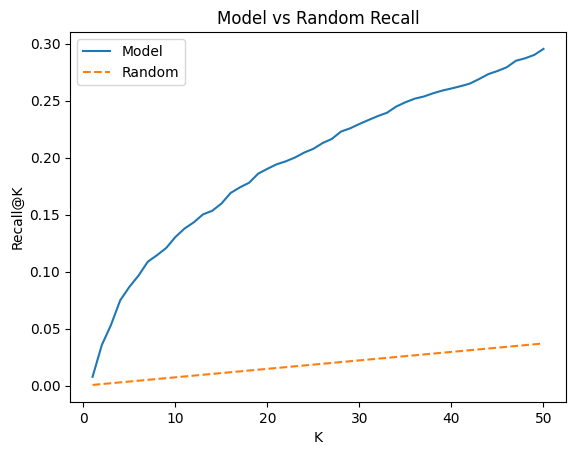

In [30]:

Ks = list(range(1, 51))
random_curve = [k / num_adrs for k in Ks]

plt.figure()
plt.plot(Ks, recall_curve, label="Model")
plt.plot(Ks, random_curve, label="Random", linestyle="--")
plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Model vs Random Recall")
plt.legend()
plt.show()

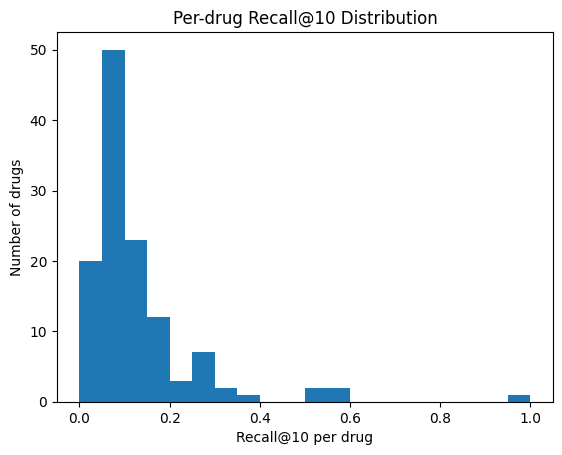

In [32]:
recalls = []

with torch.no_grad():
    for d in test_drugs:
        true_adrs = test_pos_dict[d]
        if len(true_adrs) == 0:
            continue

        scores = model(
            Gdrug_tensor[d].unsqueeze(0).repeat(num_adrs, 1),
            Gadr_tensor
        ).cpu().numpy()

        top10 = set(np.argsort(-scores)[:10])
        hits = len(top10.intersection(true_adrs))
        recalls.append(hits / len(true_adrs))

plt.figure()
plt.hist(recalls, bins=20)
plt.xlabel("Recall@10 per drug")
plt.ylabel("Number of drugs")
plt.title("Per-drug Recall@10 Distribution")
plt.show()